# Comprehensive ML Data & Model Analysis
**Purpose**: Data quality assessment, feature analysis, and model diagnostics for genomic variant classification


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Display settings for exploratory analysis
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

# Resolve the project root from the notebook location when possible.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'final_training_dataset.parquet'
df = pd.read_parquet(DATA_PATH)
print(f'Dataset path: {DATA_PATH}')
print(f'Dataset shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
display(df.head())


Dataset shape: (354290, 31)
Memory usage: 24.33 MB


## 0. First Contact With the Dataset
Before touching the model, I want to understand what one row represents, which columns look raw versus engineered, and whether the dataset already contains predictive annotation scores. This is the type of pass I would do if I had never seen the data before.


In [ ]:
print('Rows and columns:', df.shape)
print('\nColumn names in order:')
for idx, col in enumerate(df.columns, start=1):
    print(f'{idx:02d}. {col:<28} dtype={str(df[col].dtype)}')

print('\nRandom sample of 5 rows for analyst inspection:')
display(df.sample(5, random_state=42))

raw_like = ['CHROM', 'REF_Base', 'ALT_Base', 'mutation_type', 'normalized_pos', 'pos_bin']
predictive_annotation = ['SIFT', 'PolyPhen', 'CADD']
frequency_features = ['ALT_FREQ', 'freq_log', 'rare_variant', 'is_ultra_rare']
engineered_features = [
    'Is_InDel', 'Delta_Length', 'indel_size', 'Is_Frameshift', 'is_large_indel',
    'CADD_high', 'CADD_very_high', 'SIFT_damaging', 'PolyPhen_damaging',
    'CADD_x_rare', 'Impact_Score', 'rare_impact', 'pos_freq_interaction',
    'is_transition', 'is_transversion', 'chrom_freq_mean', 'chrom_rare_rate'
]

feature_groups = {
    'Raw/context-like': [c for c in raw_like if c in df.columns],
    'Predictive annotation scores': [c for c in predictive_annotation if c in df.columns],
    'Population frequency': [c for c in frequency_features if c in df.columns],
    'Engineered interactions/flags': [c for c in engineered_features if c in df.columns],
}

for group, cols in feature_groups.items():
    print(f'\n{group} ({len(cols)}): {cols}')


## 1. Data Quality Assessment


In [2]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("\n📊 MISSING VALUES:")
print(missing_df)

# Duplicate rows
duplicates = df.duplicated().sum()
print(f"\n🔄 Duplicate rows: {duplicates} ({duplicates/len(df)*100:.2f}%)")


📊 MISSING VALUES:
          Missing_Count  Percentage
PolyPhen         172738       48.76
SIFT             138249       39.02
CADD                923        0.26

🔄 Duplicate rows: 1055 (0.30%)


## 2. Target Class Distribution & Balance


### Analyst Deep Dive: Schema, Types, and Sentinel Values
The dataset has no obvious nulls after preprocessing, but genomic annotation pipelines often encode missing values as sentinel values such as `-1`. This check separates true nulls from encoded missingness.


In [ ]:
schema_audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'null_count': df.isna().sum(),
    'unique_values': df.nunique(dropna=False),
    'sample_values': [df[col].dropna().astype(str).head(4).tolist() for col in df.columns],
})
display(schema_audit)

sentinel_candidates = [-1, -1.0, 0, 'N', '-']
sentinel_rows = []
for col in df.columns:
    for value in sentinel_candidates:
        try:
            count = int((df[col] == value).sum())
        except TypeError:
            count = 0
        if count:
            sentinel_rows.append({
                'feature': col,
                'sentinel_value': value,
                'count': count,
                'percent': count / len(df) * 100,
            })

sentinel_df = pd.DataFrame(sentinel_rows).sort_values(['percent', 'feature'], ascending=[False, True])
print('Potential sentinel/default values:')
display(sentinel_df.head(40))



🎯 TARGET DISTRIBUTION:
Target
1    230682
0    123608
Name: count, dtype: int64

Class Balance:
Minority (0): 123,608 (34.89%)
Majority (1): 230,682 (65.11%)
Imbalance Ratio: 1.87:1


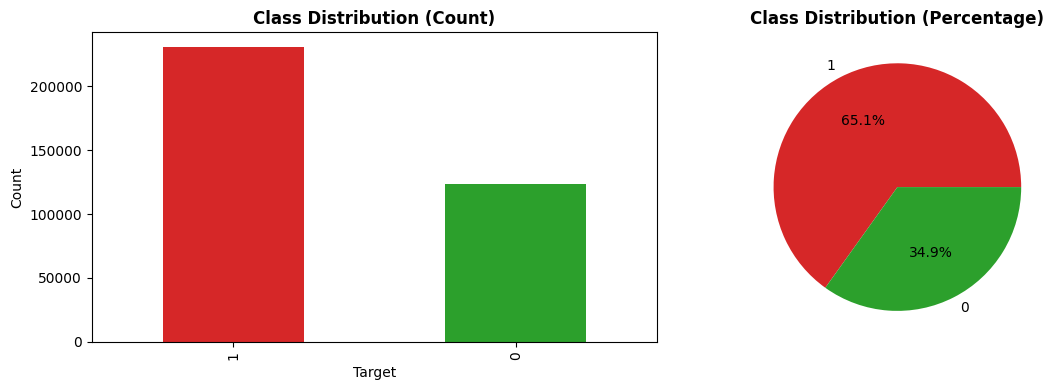

In [3]:
target_counts = df['Target'].value_counts()
print("\n🎯 TARGET DISTRIBUTION:")
print(target_counts)
print(f"\nClass Balance:")
print(f"Minority (0): {target_counts[0]:,} ({target_counts[0]/len(df)*100:.2f}%)")
print(f"Majority (1): {target_counts[1]:,} ({target_counts[1]/len(df)*100:.2f}%)")
print(f"Imbalance Ratio: {target_counts[1]/target_counts[0]:.2f}:1")

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
target_counts.plot(kind='bar', ax=ax[0], color=['#d62728', '#2ca02c'])
ax[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Count')

df['Target'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                                 colors=['#d62728', '#2ca02c'])
ax[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Feature Analysis


In [4]:
# Separate features and target
X = df.drop(columns=['Target'])
y = df['Target']

print(f"\n📈 FEATURE INFORMATION:")
print(f"Total features: {X.shape[1]}")

# Feature types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features[:5]}...")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Check for infinite values
inf_count = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
print(f"\nInfinite values: {inf_count}")

# Numeric feature statistics
print("\n📊 NUMERIC FEATURES STATISTICS:")
print(X[numeric_features].describe().round(3))


📈 FEATURE INFORMATION:
Total features: 30

Numeric features (26): ['SIFT', 'PolyPhen', 'CADD', 'ALT_FREQ', 'Is_InDel']...
Categorical features (4): ['CHROM', 'REF_Base', 'ALT_Base', 'mutation_type']

Infinite values: 0

📊 NUMERIC FEATURES STATISTICS:
             SIFT    PolyPhen        CADD    ALT_FREQ  Is_InDel  Delta_Length  \
count  216041.000  181552.000  353367.000  354290.000  354290.0      354290.0   
mean        0.204       0.536      23.398       0.006       0.0           0.0   
std         0.298       0.456      12.029       0.056       0.0           0.0   
min         0.000       0.000       0.001       0.000       0.0           0.0   
25%         0.002       0.006      16.480       0.000       0.0           0.0   
50%         0.046       0.708      24.700       0.000       0.0           0.0   
75%         0.296       0.999      32.000       0.000       0.0           0.0   
max         1.000       1.000      81.000       1.000       0.0           0.0   

       indel_size 

## 4. Feature Distributions & Outliers


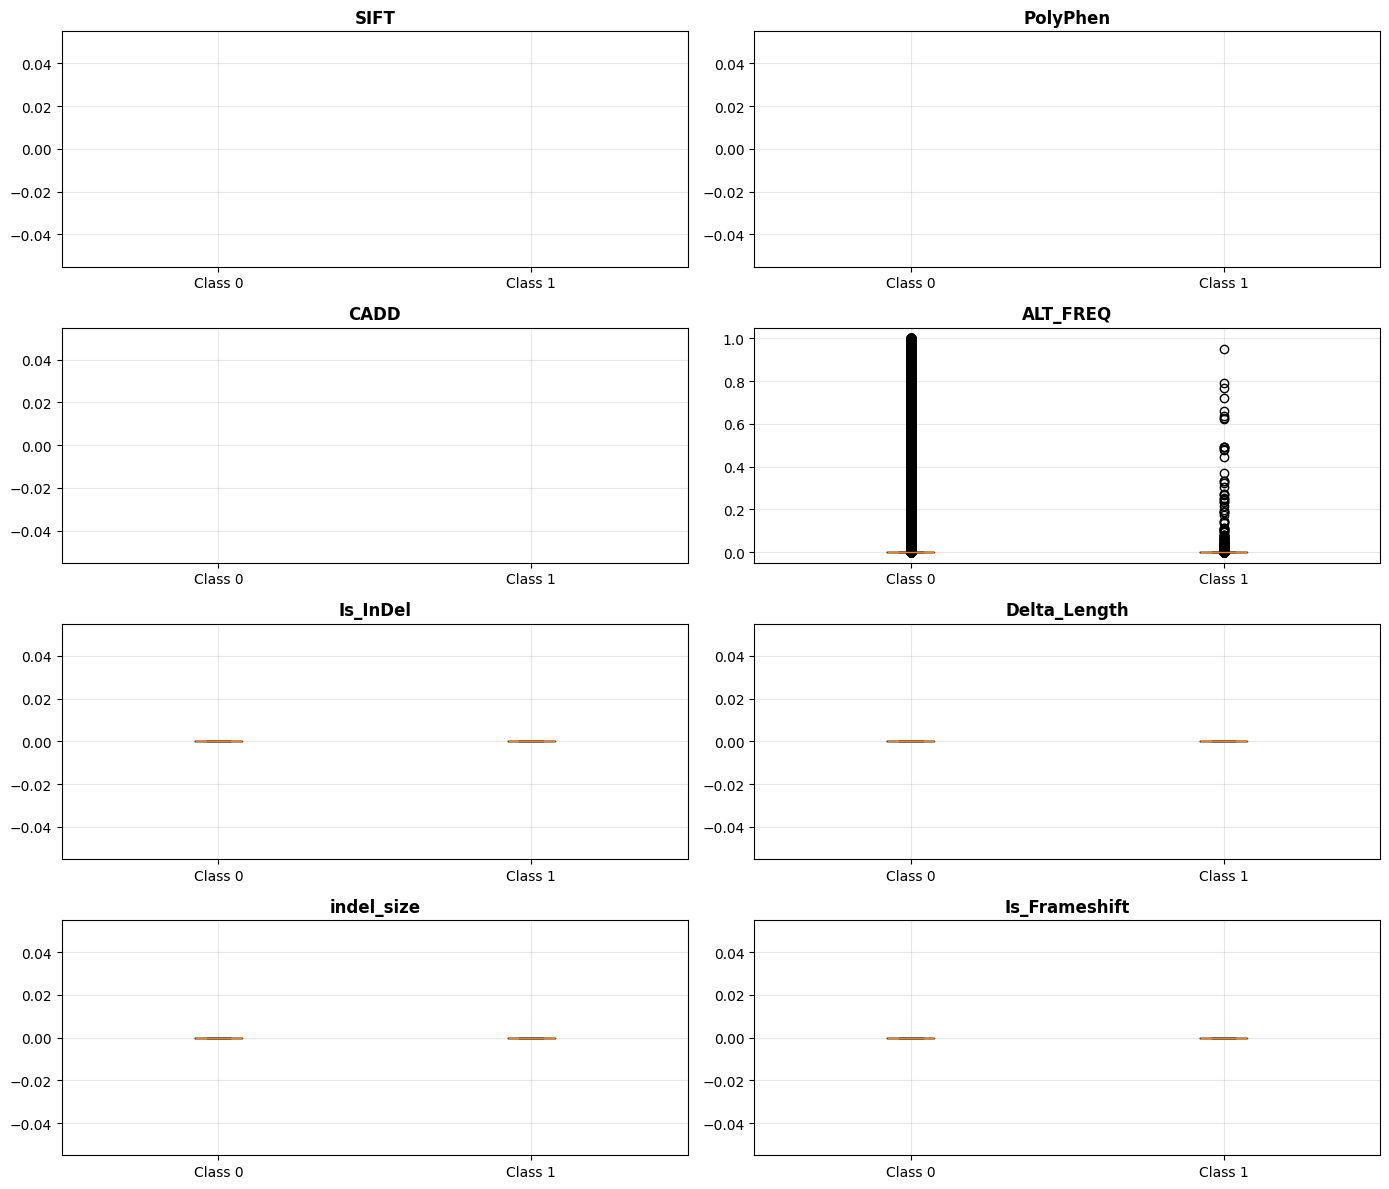


⚠️ OUTLIERS (IQR method):
PolyPhen_damaging: 87001 (24.56%)
pos_freq_interaction: 64620 (18.24%)
ALT_FREQ: 63356 (17.88%)
freq_log: 63353 (17.88%)
chrom_freq_mean: 35499 (10.02%)
is_ultra_rare: 29229 (8.25%)
SIFT: 20573 (5.81%)
rare_variant: 13633 (3.85%)
CADD: 1366 (0.39%)
CADD_x_rare: 1079 (0.30%)


In [5]:
# Box plots for numeric features
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features[:8]):
    axes[idx].boxplot([X[feature][y==0], X[feature][y==1]], labels=['Class 0', 'Class 1'])
    axes[idx].set_title(f'{feature}', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Outlier detection (IQR method)
outliers = {}
for col in numeric_features:
    Q1, Q3 = X[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outlier_mask = (X[col] < Q1 - 1.5*IQR) | (X[col] > Q3 + 1.5*IQR)
    outliers[col] = outlier_mask.sum()

print("\n⚠️ OUTLIERS (IQR method):")
for feature, count in sorted(outliers.items(), key=lambda x: x[1], reverse=True)[:10]:
    pct = count/len(X)*100
    print(f"{feature}: {count} ({pct:.2f}%)")

### Analyst Deep Dive: Categorical Cardinality and Target Lift
For categorical/context features, I want to know whether groups are well represented and whether any category has unusually high or low pathogenic rate. Tiny categories can create unstable-looking signals.


In [ ]:
cat_cols = [col for col in ['CHROM', 'REF_Base', 'ALT_Base', 'mutation_type'] if col in df.columns]
for col in cat_cols:
    summary = (
        df.groupby(col, observed=False)
        .agg(
            count=('Target', 'size'),
            pathogenic_rate=('Target', 'mean'),
        )
        .sort_values('count', ascending=False)
    )
    summary['dataset_share'] = summary['count'] / len(df)
    print(f'\n{col}: cardinality={summary.shape[0]}')
    display(summary.head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
if 'CHROM' in df.columns:
    chrom_rate = df.groupby('CHROM', observed=False)['Target'].mean().sort_index()
    chrom_rate.plot(kind='bar', ax=axes[0], color='#2563eb')
    axes[0].set_title('Pathogenic Rate by Chromosome')
    axes[0].set_ylabel('Mean Target')
    axes[0].grid(True, axis='y', alpha=0.25)

if 'mutation_type' in df.columns:
    mut_rate = (
        df.groupby('mutation_type', observed=False)['Target']
        .agg(['count', 'mean'])
        .query('count >= 100')
        .sort_values('mean', ascending=False)
        .head(15)
    )
    mut_rate['mean'].plot(kind='barh', ax=axes[1], color='#059669')
    axes[1].set_title('Top Mutation Types by Pathogenic Rate (count >= 100)')
    axes[1].set_xlabel('Mean Target')
    axes[1].grid(True, axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


## 5. Feature Correlation Analysis



🔗 FEATURE-TARGET CORRELATION (Top 15):
CADD_x_rare          0.586559
CADD                 0.556519
rare_impact          0.556229
Impact_Score         0.552101
CADD_high            0.497318
CADD_very_high       0.428463
PolyPhen             0.408288
is_ultra_rare        0.328820
rare_variant         0.253953
is_transversion      0.113093
PolyPhen_damaging    0.103585
SIFT_damaging        0.078396
chrom_rare_rate      0.061360
pos_bin             -0.006121
normalized_pos      -0.014757
dtype: float64


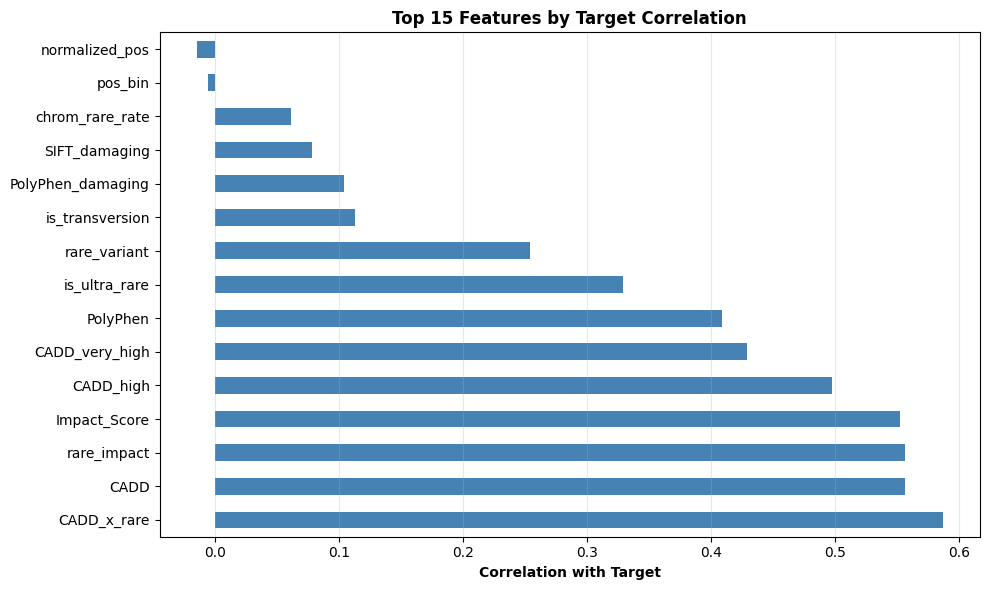


⚠️ HIGH MULTICOLLINEARITY (|r| > 0.9):
is_transition <-> is_transversion: -1.000
ALT_FREQ <-> freq_log: 0.996
Impact_Score <-> rare_impact: 0.983
CADD <-> CADD_x_rare: 0.966
chrom_freq_mean <-> chrom_rare_rate: -0.949
PolyPhen <-> PolyPhen_damaging: 0.936
normalized_pos <-> pos_bin: 0.925


In [6]:
# Correlation with target
correlations = X[numeric_features].corrwith(y).sort_values(ascending=False)
print("\n🔗 FEATURE-TARGET CORRELATION (Top 15):")
print(correlations.head(15))

# Visualize correlations with target
fig, ax = plt.subplots(figsize=(10, 6))
correlations.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Correlation with Target', fontweight='bold')
ax.set_title('Top 15 Features by Target Correlation', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Check for multicollinearity
corr_matrix = X[numeric_features].corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️ HIGH MULTICOLLINEARITY (|r| > 0.9):")
    for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{f1} <-> {f2}: {corr:.3f}")
else:
    print("\n✅ No high multicollinearity detected (|r| > 0.9)")

### Analyst Deep Dive: Numeric Feature Separation by Target
This view asks a simple analyst question: which numeric variables look meaningfully different between benign and pathogenic records before any model is trained?


In [ ]:
separation_rows = []
for col in numeric_features:
    benign = df.loc[df['Target'] == 0, col]
    pathogenic = df.loc[df['Target'] == 1, col]
    pooled_std = df[col].std()
    mean_delta = pathogenic.mean() - benign.mean()
    separation_rows.append({
        'feature': col,
        'benign_mean': benign.mean(),
        'pathogenic_mean': pathogenic.mean(),
        'mean_delta': mean_delta,
        'standardized_delta': mean_delta / pooled_std if pooled_std else 0,
        'benign_median': benign.median(),
        'pathogenic_median': pathogenic.median(),
    })

separation_df = pd.DataFrame(separation_rows)
separation_df['abs_standardized_delta'] = separation_df['standardized_delta'].abs()
separation_df = separation_df.sort_values('abs_standardized_delta', ascending=False)
display(separation_df.head(20))

fig, ax = plt.subplots(figsize=(10, 6))
separation_df.head(15).sort_values('standardized_delta').plot(
    x='feature', y='standardized_delta', kind='barh', ax=ax, color='#7c3aed', legend=False
)
ax.set_title('Largest Standardized Mean Differences by Target')
ax.set_xlabel('Standardized Mean Difference')
ax.grid(True, axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Model Diagnostics - Load & Evaluate


In [7]:
import mlflow
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Load trained model
mlflow.set_tracking_uri('file:///home/badr/genomic-variant-mlops/mlruns')
RUN_ID = 'dbe417271eaa42e29383c802ed61e11f'
MODEL_URI = f'runs:/{RUN_ID}/model'

model = mlflow.xgboost.load_model(MODEL_URI)
print(f"✅ Model loaded successfully from Run ID: {RUN_ID}")
print(f"\nModel type: {type(model).__name__}")
print(f"Model parameters (key ones):")
print(f"  - max_depth: {model.max_depth}")
print(f"  - n_estimators: {model.n_estimators}")
print(f"  - learning_rate: {model.learning_rate}")
print(f"  - scale_pos_weight: {model.scale_pos_weight}")

✅ Model loaded successfully from Run ID: dbe417271eaa42e29383c802ed61e11f

Model type: XGBClassifier
Model parameters (key ones):
  - max_depth: None
  - n_estimators: None
  - learning_rate: None
  - scale_pos_weight: None


## 7. Cross-Validation & Generalization


### Analyst Deep Dive: Predictive Annotation Dependence Check
Because `SIFT`, `PolyPhen`, and `CADD` are already pathogenicity-oriented annotation scores, I want to explicitly inspect how much they dominate simple relationships with the target. This helps frame the model as an annotation-evidence aggregator rather than a from-scratch biological discovery model.


In [ ]:
predictive_cols = [col for col in ['SIFT', 'PolyPhen', 'CADD'] if col in df.columns]
context_cols = [col for col in numeric_features if col not in predictive_cols]

print('Predictive annotation score correlations:')
display(correlations.loc[predictive_cols].to_frame('target_correlation'))

print('\nTop non-predictive/context numeric correlations:')
display(correlations.loc[context_cols].abs().sort_values(ascending=False).head(15).to_frame('absolute_target_correlation'))

fig, axes = plt.subplots(1, len(predictive_cols), figsize=(5 * len(predictive_cols), 4))
if len(predictive_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, predictive_cols):
    sns.kdeplot(data=df.sample(min(len(df), 60000), random_state=42), x=col, hue='Target', common_norm=False, ax=ax)
    ax.set_title(f'{col} Distribution by Target')
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [8]:
# Stratified K-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Multiple metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

print("\n📊 CROSS-VALIDATION RESULTS (5-Fold):")
for metric, scores in cv_results.items():
    if metric.startswith('test_'):
        metric_name = metric.replace('test_', '').upper()
        print(f"\n{metric_name}:")
        print(f"  Scores: {scores}")
        print(f"  Mean: {scores.mean():.4f}")
        print(f"  Std:  {scores.std():.4f}")
        print(f"  Range: [{scores.min():.4f}, {scores.max():.4f}]")


📊 CROSS-VALIDATION RESULTS (5-Fold):

ROC_AUC:
  Scores: [0.92897229 0.92890076 0.92939131 0.92943035 0.9305402 ]
  Mean: 0.9294
  Std:  0.0006
  Range: [0.9289, 0.9305]

ACCURACY:
  Scores: [0.8512518  0.85041915 0.85142115 0.85142115 0.85348161]
  Mean: 0.8516
  Std:  0.0010
  Range: [0.8504, 0.8535]

PRECISION:
  Scores: [0.89763181 0.89739002 0.89478469 0.8978037  0.90013205]
  Mean: 0.8975
  Std:  0.0017
  Range: [0.8948, 0.9001]

RECALL:
  Scores: [0.87086007 0.86971129 0.8746532  0.87094956 0.8716865 ]
  Mean: 0.8716
  Std:  0.0017
  Range: [0.8697, 0.8747]

F1:
  Scores: [0.8840433  0.88333388 0.88460442 0.88417277 0.88568094]
  Mean: 0.8844
  Std:  0.0008
  Range: [0.8833, 0.8857]


## 8. Feature Importance Analysis



🎯 FEATURE IMPORTANCE (Top 20):
             Feature  Importance
        Impact_Score    0.369676
         CADD_x_rare    0.205971
         rare_impact    0.161328
       is_ultra_rare    0.050540
                CADD    0.037752
            freq_log    0.031292
      CADD_very_high    0.030699
            ALT_FREQ    0.026493
               CHROM    0.010090
pos_freq_interaction    0.009770
                SIFT    0.008793
      normalized_pos    0.006861
   PolyPhen_damaging    0.006447
       SIFT_damaging    0.006411
            PolyPhen    0.006069
             pos_bin    0.005559
     chrom_rare_rate    0.005262
     chrom_freq_mean    0.005209
       mutation_type    0.003561
           CADD_high    0.002688


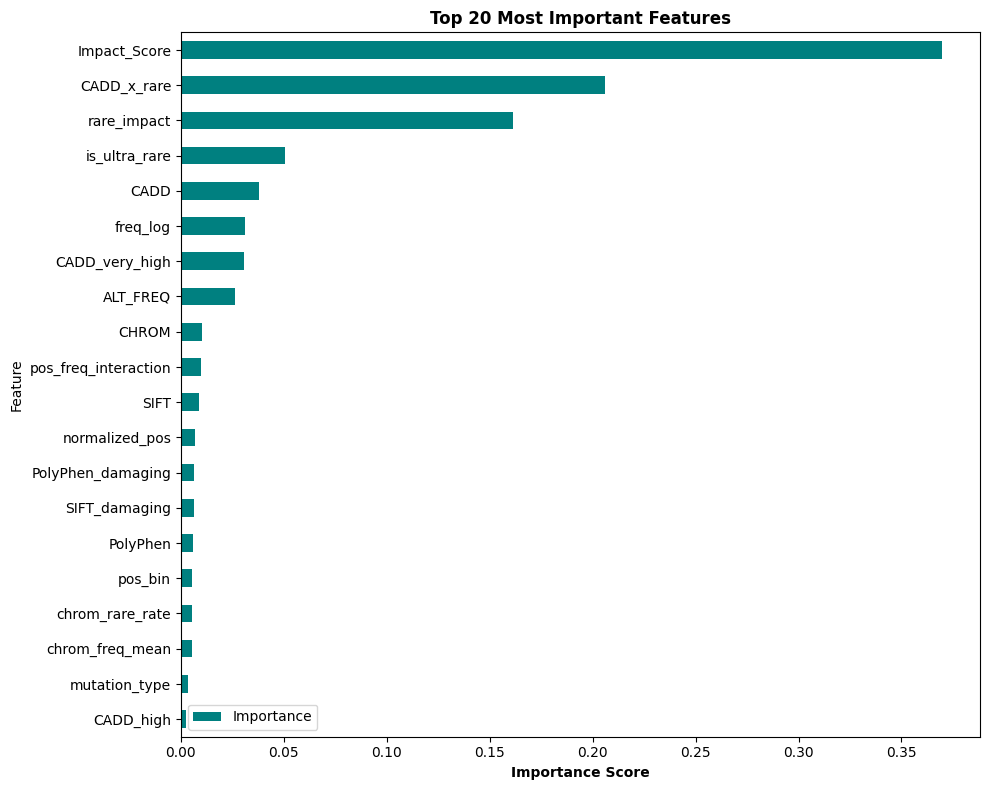


📌 Features needed for 90% importance: 8 out of 30


In [9]:
# Get feature importance
importances = model.feature_importances_
feature_names = X.columns

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n🎯 FEATURE IMPORTANCE (Top 20):")
print(importance_df.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
importance_df.head(20).plot(x='Feature', y='Importance', kind='barh', ax=ax, color='teal')
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Top 20 Most Important Features', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Cumulative importance
cumsum = importance_df['Importance'].cumsum() / importance_df['Importance'].sum()
n_features_90 = (cumsum <= 0.9).sum() + 1
print(f"\n📌 Features needed for 90% importance: {n_features_90} out of {len(feature_names)}")

### Analyst Notes Before Modeling
These notes capture what I would tell the modeling team before trusting any benchmark.


In [ ]:
notes = []
if set(['SIFT', 'PolyPhen', 'CADD']).issubset(df.columns):
    notes.append('SIFT, PolyPhen, and CADD are predictive annotation scores; model claims should describe evidence aggregation, not raw-sequence discovery.')
if not missing_df.empty:
    notes.append('There are true missing values that need explicit handling.')
else:
    notes.append('No true nulls were found after preprocessing, but sentinel defaults still need interpretation.')
if duplicates:
    notes.append(f'{duplicates:,} duplicate full rows were found and should be reviewed before final training.')
if target_counts.max() / target_counts.min() > 1.5:
    notes.append('The target is moderately imbalanced; PR-AUC is more informative than accuracy.')
notes.append('Random stratified splits are useful for first checks but should be complemented with chromosome/gene/temporal validation.')
notes.append('The prior ablation without SIFT/PolyPhen/CADD reached PR-AUC around 0.59, so benchmark results should include feature-set ablations.')

for idx, note in enumerate(notes, start=1):
    print(f'{idx}. {note}')


## 9. Data Quality Recommendations


In [11]:
recommendations = []

# Check 1: Missing values
if missing_df.shape[0] > 0:
    recommendations.append("⚠️ MISSING VALUES: Handle missing data with imputation or removal")
else:
    recommendations.append("✅ No missing values detected")

# Check 2: Duplicates
if duplicates > 0:
    recommendations.append(f"⚠️ DUPLICATES: Remove {duplicates} duplicate rows")
else:
    recommendations.append("✅ No duplicate rows")

# Check 3: Class imbalance
imbalance_ratio = target_counts[1] / target_counts[0]
if imbalance_ratio > 2:
    recommendations.append(f"⚠️ CLASS IMBALANCE: Severe imbalance detected ({imbalance_ratio:.2f}:1). Model already uses scale_pos_weight remediation.")
elif imbalance_ratio > 1.5:
    recommendations.append(f"⚠️ CLASS IMBALANCE: Moderate imbalance ({imbalance_ratio:.2f}:1). Remediation via scale_pos_weight is adequate.")
else:
    recommendations.append("✅ Data is balanced")

# Check 4: Feature correlations
if high_corr_pairs:
    recommendations.append(f"⚠️ MULTICOLLINEARITY: {len(high_corr_pairs)} feature pairs with |r| > 0.9. Consider removing one feature from each pair.")
else:
    recommendations.append("✅ No high multicollinearity detected")

# Check 5: Outliers
high_outlier_features = [f for f, c in outliers.items() if c > len(X) * 0.05]
if high_outlier_features:
    recommendations.append(f"⚠️ OUTLIERS: Features with >5% outliers: {high_outlier_features}. Verify domain relevance.")
else:
    recommendations.append("✅ Outlier levels are reasonable")

print("\n" + "="*70)
print("📋 ML ENGINEER RECOMMENDATIONS")
print("="*70)
for rec in recommendations:
    print(f"\n{rec}")
print("\n" + "="*70)


📋 ML ENGINEER RECOMMENDATIONS

⚠️ MISSING VALUES: Handle missing data with imputation or removal

⚠️ DUPLICATES: Remove 1055 duplicate rows

⚠️ CLASS IMBALANCE: Moderate imbalance (1.87:1). Remediation via scale_pos_weight is adequate.

⚠️ MULTICOLLINEARITY: 7 feature pairs with |r| > 0.9. Consider removing one feature from each pair.

⚠️ OUTLIERS: Features with >5% outliers: ['SIFT', 'ALT_FREQ', 'freq_log', 'is_ultra_rare', 'PolyPhen_damaging', 'pos_freq_interaction', 'chrom_freq_mean']. Verify domain relevance.



## Candidate Model Benchmark Evidence
The production model should not be justified only by intuition. This section records the current benchmark evidence comparing XGBoost with simpler baselines on the same held-out protocol.


In [ ]:
benchmark_path = PROJECT_ROOT / 'docs' / 'model_benchmark_results.csv'
if benchmark_path.exists():
    benchmark_df = pd.read_csv(benchmark_path)
    display(benchmark_df)
    winner = benchmark_df.sort_values(['pr_auc', 'f1_score'], ascending=False).iloc[0]
    print(f"Best benchmark model: {winner['model']} with PR-AUC={winner['pr_auc']:.4f} and F1={winner['f1_score']:.4f}")
else:
    print('Benchmark results not found yet. Run:')
    print('python -m src.model.benchmark_models --sample-size 100000')
